## ✈ Crew Recovery Recommendation System ✈

### Crew Recovery Recommendation System Overview
We will build a system that could evaluate flight disruptions and recommend the most optimal backup crew:
* Crew A: Assigned to high-risk, severe disruptions.
* Crew B: Assigned to moderate-risk, standard disruptions.
* Crew C: Assigned to low-risk disruptions to preserve primary standby resources.

In [ ]:
import pandas as pd
import numpy as np

# Generate simulated flight disruption scenarios
np.random.seed(42)
n_scenarios = 200

inbound_delay = np.random.uniform(10, 120, n_scenarios)
hub_congestion = np.random.uniform(20, 100, n_scenarios)
crew_buffer = np.random.uniform(15, 90, n_scenarios)

df = pd.DataFrame({
    'inbound_delay_mins': np.round(inbound_delay, 1),
    'hub_congestion_pct': np.round(hub_congestion, 1),
    'crew_buffer_mins': np.round(crew_buffer, 1)
})

display(df.head())

,inbound_delay_mins,hub_congestion_pct,crew_buffer_mins
0,51.2,71.4,22.7
1,114.6,26.7,82.7
2,90.5,32.9,52.9
3,75.9,91.9,77.0
4,27.2,68.5,39.0


In [ ]:
def recommend_crew_recovery(row):
    # Calculate a simplified heuristic risk score from 0 to 100
    delay_factor = row['inbound_delay_mins'] * 0.5
    congestion_factor = row['hub_congestion_pct'] * 0.3
    buffer_factor = (90 - row['crew_buffer_mins']) * 0.2
    risk_score = delay_factor + congestion_factor + buffer_factor

    if risk_score > 65:
        return 'Crew A'
    elif risk_score > 35:
        return 'Crew B'
    else:
        return 'Crew C'

df['recommended_crew'] = df.apply(recommend_crew_recovery, axis=1)

print("Value counts of recommended recovery options:")
print(df['recommended_crew'].value_counts())
display(df.head(10))

Value counts of recommended recovery options:
recommended_crew
Crew B    104
Crew A     72
Crew C     24
Name: count, dtype: int64


,inbound_delay_mins,hub_congestion_pct,crew_buffer_mins,recommended_crew
0,51.2,71.4,22.7,Crew B
1,114.6,26.7,82.7,Crew A
2,90.5,32.9,52.9,Crew B
3,75.9,91.9,77.0,Crew A
4,27.2,68.5,39.0,Crew B
5,27.2,20.7,82.2,Crew C
6,16.4,28.1,44.2,Crew C
7,105.3,73.1,15.8,Crew A
8,76.1,20.4,82.9,Crew B
9,87.9,32.9,21.8,Crew A


### Visualize the Distribution of Assigned Crews using a Bar Chart
We will create a visualization using a bar chart to display the distribution of the assigned standby crews (Crew A, Crew B, and Crew C).

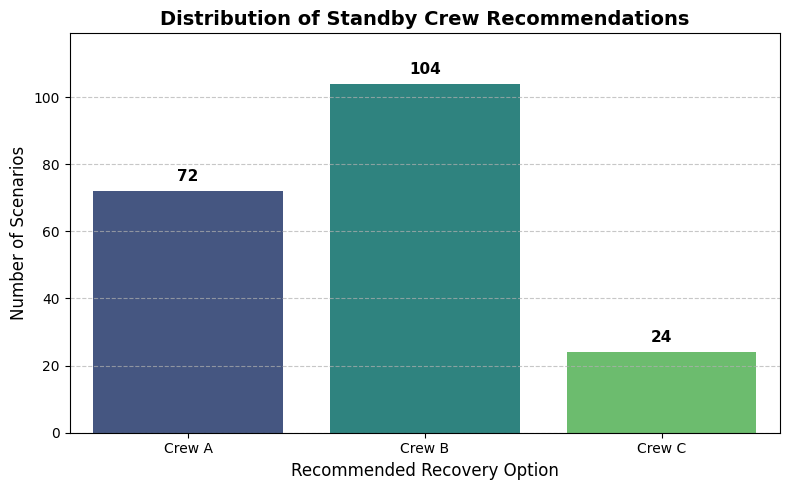

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the frequency of each recommended crew
crew_counts = df['recommended_crew'].value_counts().reindex(['Crew A', 'Crew B', 'Crew C'])

# Plotting the bar chart
plt.figure(figsize=(8, 5))
sns.barplot(x=crew_counts.index, y=crew_counts.values, palette='viridis', hue=crew_counts.index, legend=False)

# Customizing the chart labels and title
plt.title('Distribution of Standby Crew Recommendations', fontsize=14, fontweight='bold')
plt.xlabel('Recommended Recovery Option', fontsize=12)
plt.ylabel('Number of Scenarios', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add exact count on top of each bar
for idx, value in enumerate(crew_counts.values):
    plt.text(idx, value + 2, str(value), ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.ylim(0, max(crew_counts.values) + 15)
plt.tight_layout()
plt.show()

### Box Plot of inbound_delay_mins by recommended_crew
We will create a box plot to visualize the distribution of inbound delay minutes for each recommended crew type.

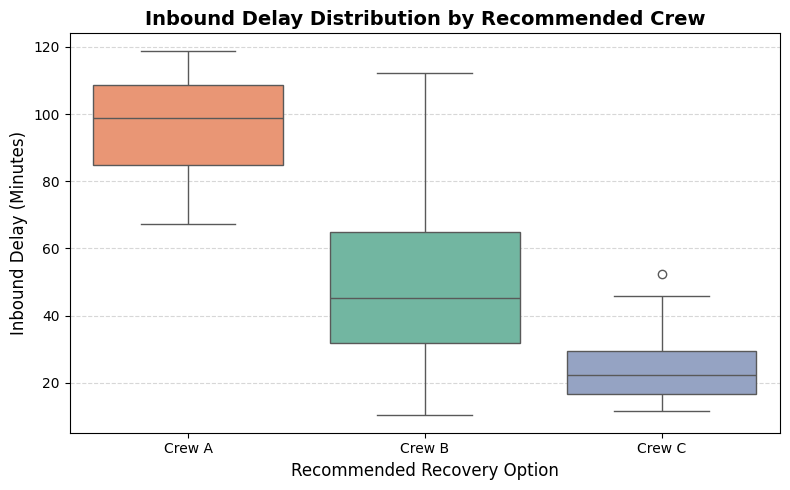

In [ ]:
# Plotting a box plot to show the relationship between Inbound Delay and Recommended Crew
plt.figure(figsize=(8, 5))
sns.boxplot(x='recommended_crew', y='inbound_delay_mins', data=df, order=['Crew A', 'Crew B', 'Crew C'], palette='Set2', hue='recommended_crew', legend=False)

# Customizing labels and title
plt.title('Inbound Delay Distribution by Recommended Crew', fontsize=14, fontweight='bold')
plt.xlabel('Recommended Recovery Option', fontsize=12)
plt.ylabel('Inbound Delay (Minutes)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Average Risk Score for Each Crew Assignment
We will calculate the average risk score for each of our crew recommendations (Crew A, Crew B, and Crew C) so we can see the numeric range boundaries mapped to each group.

In [ ]:
# Calculate the risk score for each row in the dataset
df['risk_score'] = (
    df['inbound_delay_mins'] * 0.5 +
    df['hub_congestion_pct'] * 0.3 +
    (90 - df['crew_buffer_mins']) * 0.2
)

# Group by recommended crew and calculate the mean risk score
avg_risk_scores = df.groupby('recommended_crew')['risk_score'].mean().reset_index()
avg_risk_scores.columns = ['Recommended Crew', 'Average Risk Score']

display(avg_risk_scores)

,Recommended Crew,Average Risk Score
0,Crew A,77.003333
1,Crew B,50.079038
2,Crew C,26.286667


### Sensitivity Analysis of Risk Score Thresholds

We will define several threshold scenarios to evaluate how varying the cut-offs for Crew A (High-Risk) and Crew C (Low-Risk) affects the overall allocation of standby resources.

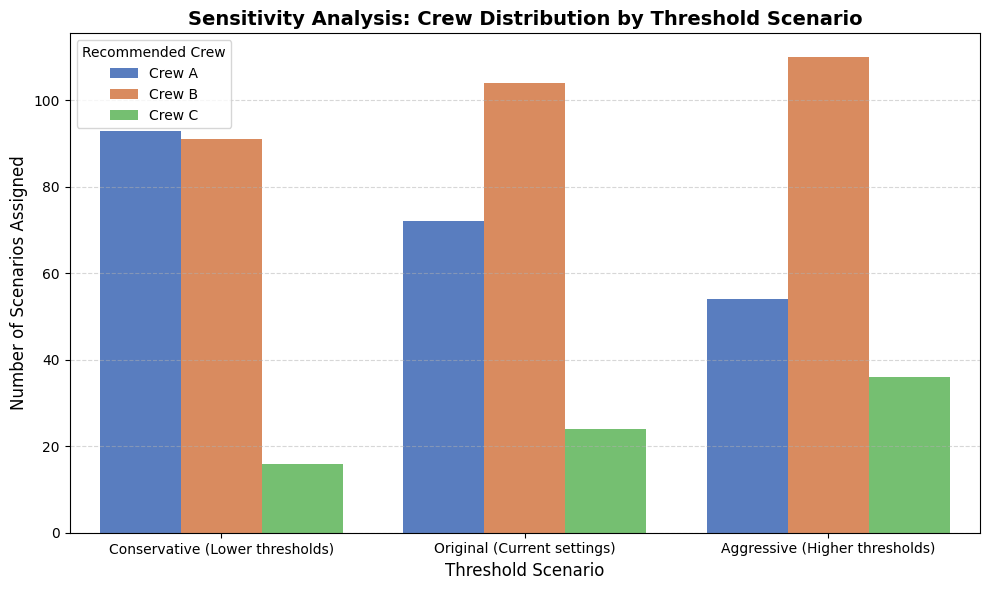

Recommended Crew,Crew A,Crew B,Crew C
Scenario,,,
Aggressive (Higher thresholds),54,110,36
Conservative (Lower thresholds),93,91,16
Original (Current settings),72,104,24


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define alternative threshold scenarios: (Crew C limit, Crew A limit)
threshold_scenarios = {
    'Conservative (Lower thresholds)': (30, 60),
    'Original (Current settings)': (35, 65),
    'Aggressive (Higher thresholds)': (40, 70)
}

sensitivity_results = []

for scenario_name, (low_limit, high_limit) in threshold_scenarios.items():
    # Classify crews based on the scenario thresholds
    def classify(score):
        if score > high_limit:
            return 'Crew A'
        elif score > low_limit:
            return 'Crew B'
        else:
            return 'Crew C'

    temp_series = df['risk_score'].apply(classify)
    counts = temp_series.value_counts().reindex(['Crew A', 'Crew B', 'Crew C']).fillna(0)

    for crew, count in counts.items():
        sensitivity_results.append({
            'Scenario': scenario_name,
            'Recommended Crew': crew,
            'Count': int(count)
        })

sensitivity_df = pd.DataFrame(sensitivity_results)

# Visualize the sensitivity analysis results
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Scenario',
    y='Count',
    hue='Recommended Crew',
    data=sensitivity_df,
    palette='muted'
)

plt.title('Sensitivity Analysis: Crew Distribution by Threshold Scenario', fontsize=14, fontweight='bold')
plt.xlabel('Threshold Scenario', fontsize=12)
plt.ylabel('Number of Scenarios Assigned', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Recommended Crew')

plt.tight_layout()
plt.show()

# Display the structured summary table
pivot_df = sensitivity_df.pivot(index='Scenario', columns='Recommended Crew', values='Count')
display(pivot_df)